<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-49-random-forest-intuition-code?scriptVersionId=350585840" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🌲 ML 49 — Random Forest | Intuition & Code

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, BaggingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import make_classification, make_circles
from sklearn.metrics import accuracy_score

In [121]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [122]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])

df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.819585,-2.489461,-1.447104,-0.390180,0.060378,1
1,0.049223,0.754069,2.402771,-0.311135,-0.867502,0
2,-1.099016,2.525948,1.647849,-2.345282,-1.828175,0
3,-0.611150,-0.537876,-1.280017,-0.564887,-1.876185,1
4,-1.182671,-0.545976,-1.213598,-0.888984,-0.641673,1


In [123]:
# function for row sampling

def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [124]:
# function for feature sampling

def sample_features(df, percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [125]:
# function for combined sampling

def combined_sampling(df, row_percent, col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [126]:
df1 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_58/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [127]:
df2 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_58/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [128]:
df3 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_58/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [129]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col1', 'target'], dtype='object')
Index(['col3', 'col4', 'target'], dtype='object')
Index(['col5', 'col2', 'target'], dtype='object')


In [130]:
clf1 = DecisionTreeClassifier(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = DecisionTreeClassifier(random_state=42)

In [131]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier(random_state=42)

[Text(0.5, 0.9, 'x[0] <= -0.71\ngini = 0.48\nsamples = 50\nvalue = [30, 20]'),
 Text(0.2777777777777778, 0.7, 'x[1] <= -1.213\ngini = 0.367\nsamples = 33\nvalue = [25, 8]'),
 Text(0.3888888888888889, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'x[1] <= -1.911\ngini = 0.463\nsamples = 11\nvalue = [4, 7]'),
 Text(0.1111111111111111, 0.3, 'x[1] <= -2.295\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.05555555555555555, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.16666666666666666, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.2222222222222222, 0.3, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.3888888888888889, 0.5, 'x[0] <= -1.582\ngini = 0.087\nsamples = 22\nvalue = [21, 1]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.4444444444444444, 0.3, 'x[0] <= -1.496\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.3888888888888889, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.1, 'gini = 0.0\ns

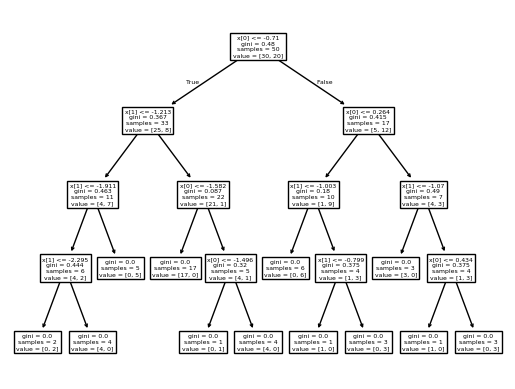

In [132]:
from sklearn.tree import plot_tree

plot_tree(clf1)

[Text(0.5, 0.9285714285714286, 'x[0] <= 1.019\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.42857142857142855, 0.7857142857142857, 'x[0] <= -1.442\ngini = 0.438\nsamples = 37\nvalue = [12, 25]'),
 Text(0.4642857142857143, 0.8571428571428572, 'True  '),
 Text(0.21428571428571427, 0.6428571428571429, 'x[1] <= -0.767\ngini = 0.133\nsamples = 14\nvalue = [1, 13]'),
 Text(0.14285714285714285, 0.5, 'x[1] <= -1.0\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.07142857142857142, 0.35714285714285715, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.21428571428571427, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2857142857142857, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.6428571428571429, 0.6428571428571429, 'x[0] <= -0.683\ngini = 0.499\nsamples = 23\nvalue = [11, 12]'),
 Text(0.42857142857142855, 0.5, 'x[1] <= -0.497\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.35714285714285715, 0.35714285714285715, 'gini = 0.0\nsamples = 1

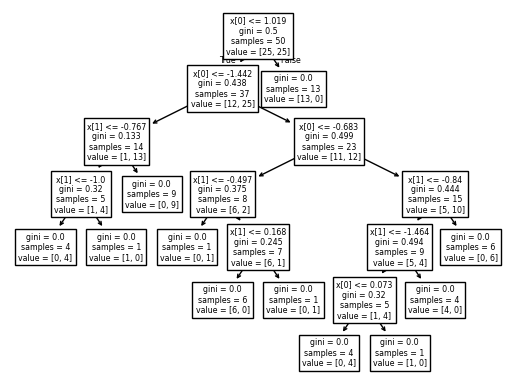

In [133]:
plot_tree(clf2)

[Text(0.6785714285714286, 0.9444444444444444, 'x[1] <= 0.13\ngini = 0.487\nsamples = 50\nvalue = [29.0, 21.0]'),
 Text(0.5, 0.8333333333333334, 'x[1] <= -0.708\ngini = 0.5\nsamples = 39\nvalue = [20, 19]'),
 Text(0.5892857142857143, 0.8888888888888888, 'True  '),
 Text(0.2857142857142857, 0.7222222222222222, 'x[0] <= 0.175\ngini = 0.459\nsamples = 28\nvalue = [18, 10]'),
 Text(0.23809523809523808, 0.6111111111111112, 'x[0] <= -1.129\ngini = 0.499\nsamples = 21\nvalue = [11, 10]'),
 Text(0.14285714285714285, 0.5, 'x[1] <= -1.974\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.09523809523809523, 0.3888888888888889, 'x[1] <= -2.273\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.047619047619047616, 0.2777777777777778, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.14285714285714285, 0.2777777777777778, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.19047619047619047, 0.3888888888888889, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.3333333333333333, 0.5, 'x[0] <=

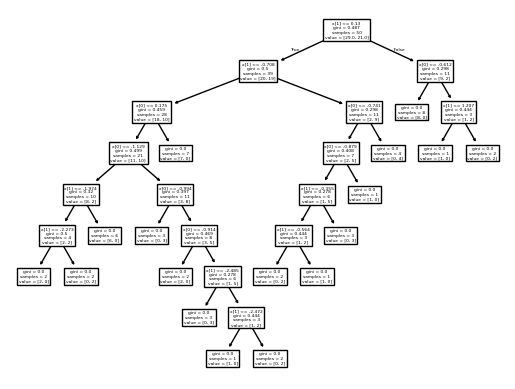

In [134]:
plot_tree(clf3)

In [135]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [136]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [137]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

# Random Forest Demo

In [138]:
np.random.seed(42)

X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

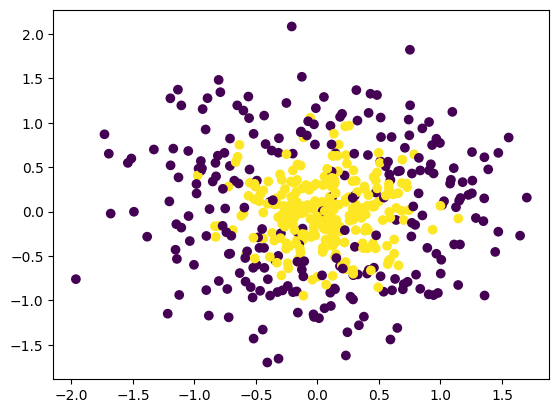

In [139]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

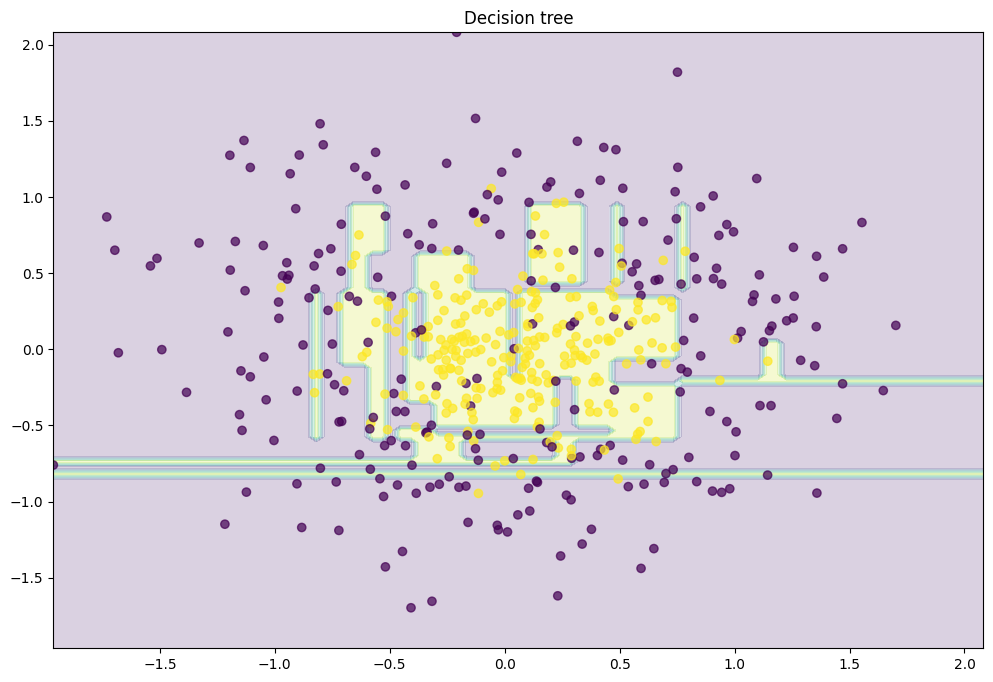

In [140]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()

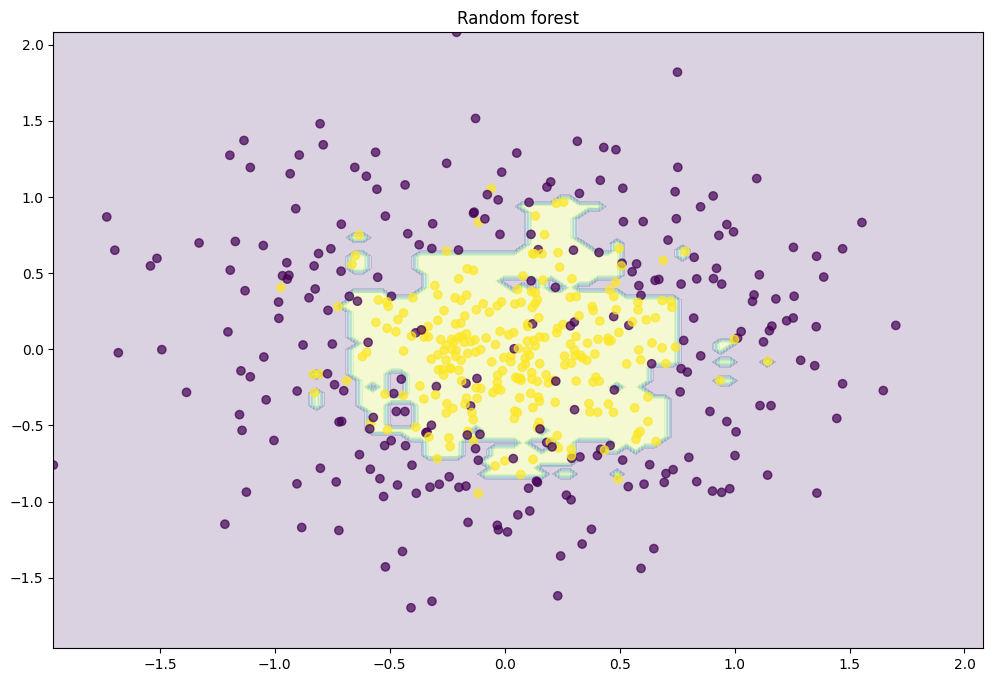

In [141]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()

In [142]:
n_train = 150        
n_test = 1000       
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

In [143]:
X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

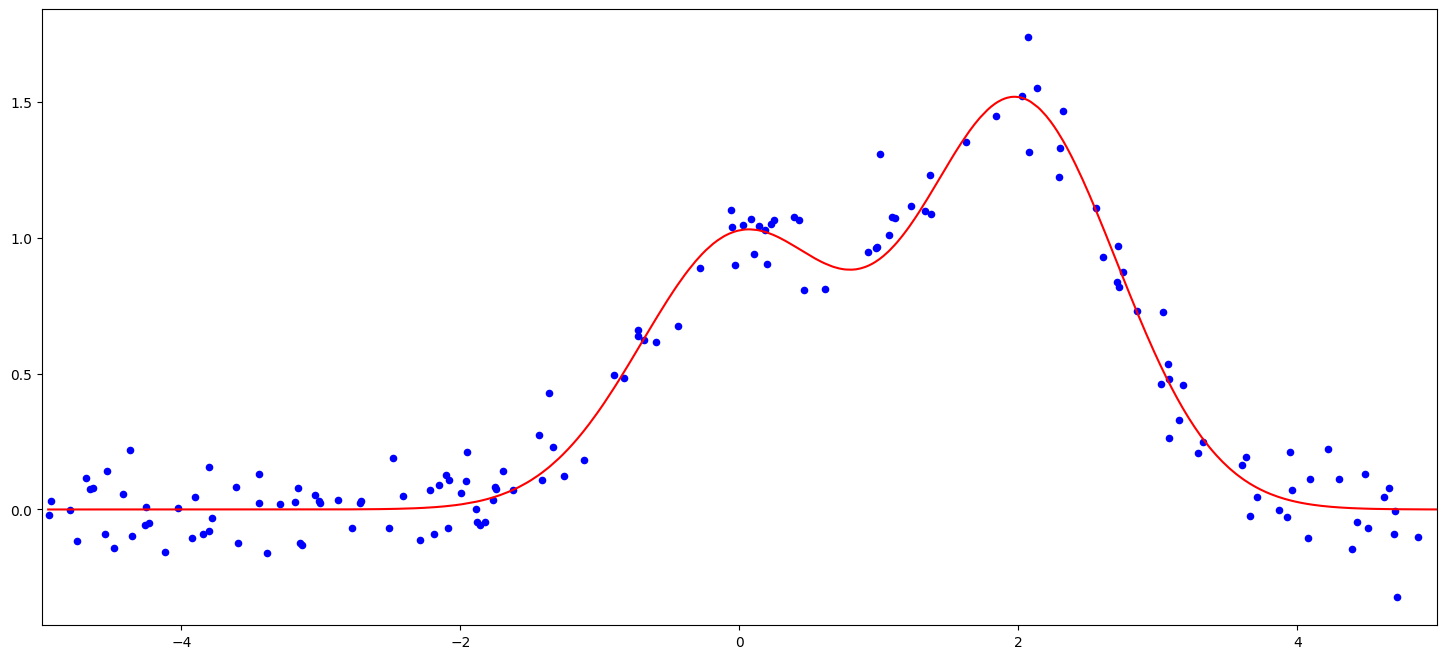

In [144]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])
plt.show()

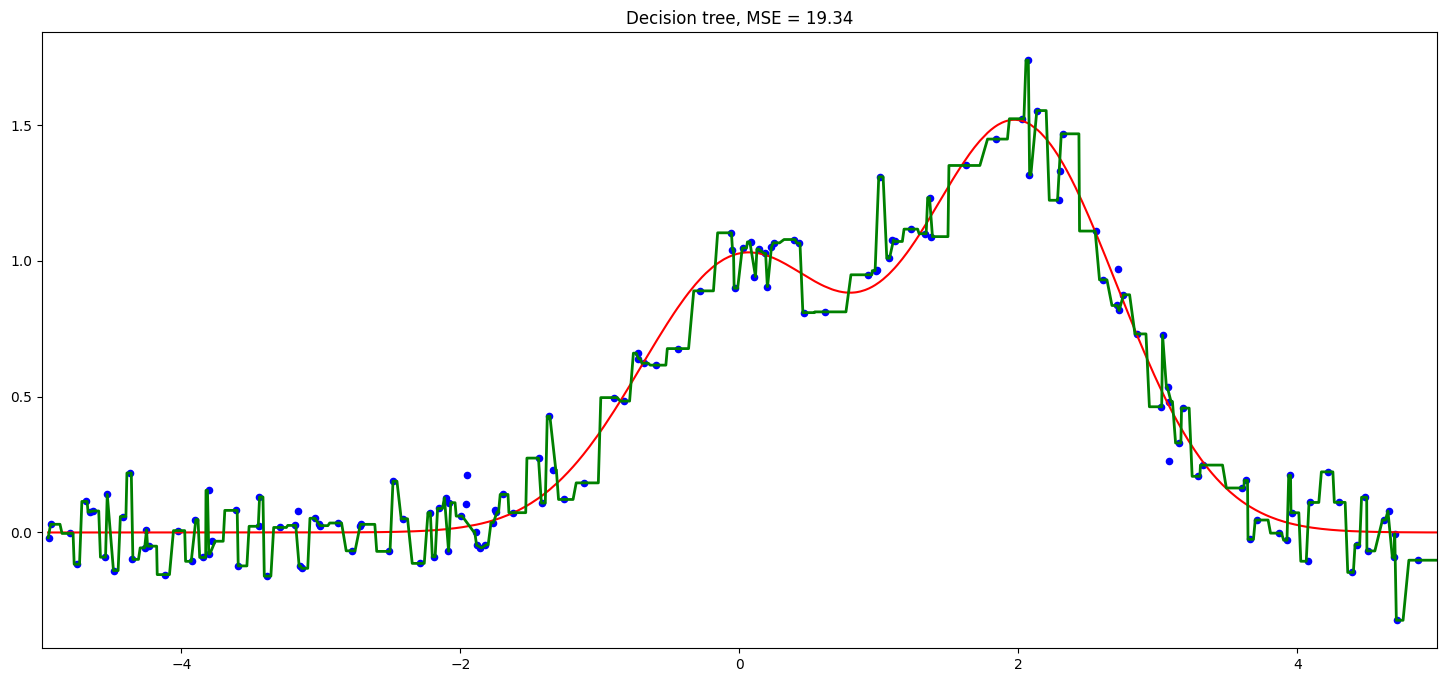

In [145]:
dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" 
          % np.sum((y_test - d_predict) ** 2))
plt.show()

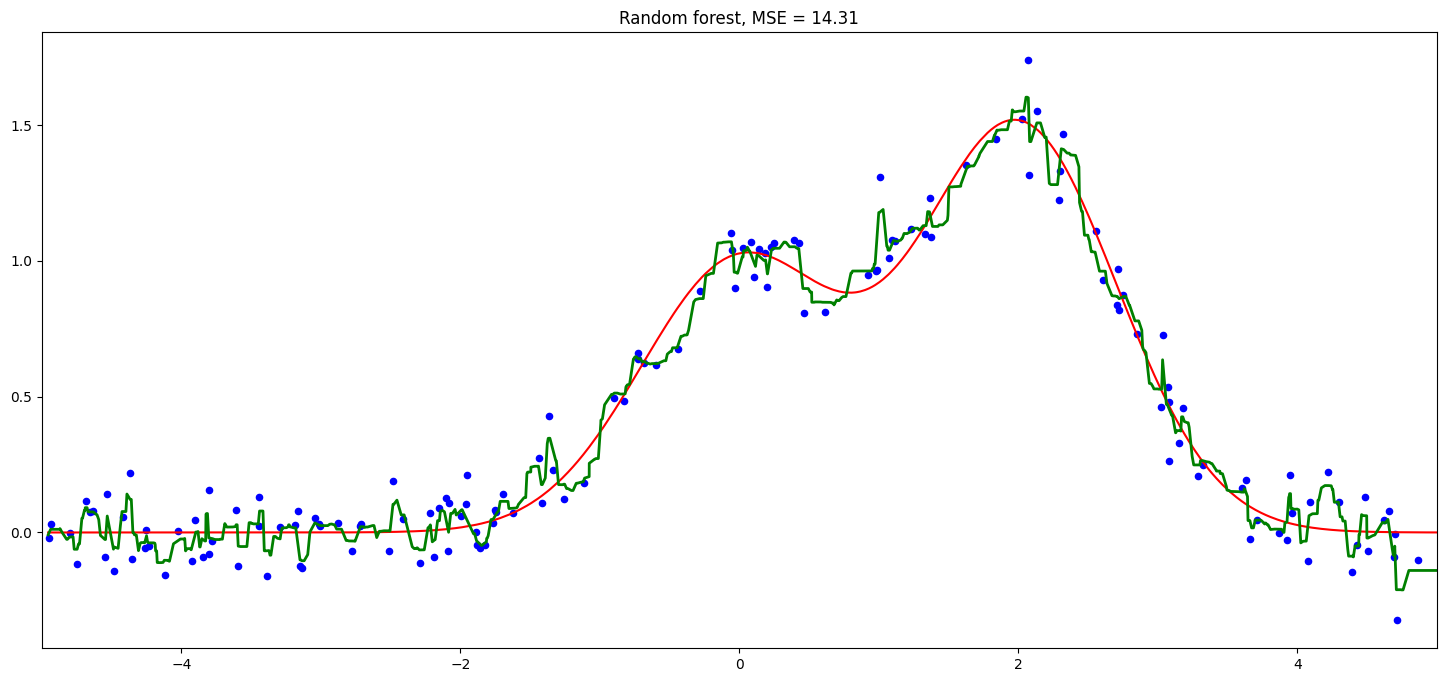

In [146]:
rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2))
plt.show()

# Bagging Vs Random Forest

* Bagging -> Tree Based ...
* Random Forest -> Node Based ...

In [147]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [148]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.524379,-0.239080,0.304957,0.267119,-0.889149,0
1,0.818277,-2.156742,0.246023,0.111282,-0.710882,1
2,0.677754,-1.778875,-1.273572,2.080113,2.538501,0
3,1.190280,-2.725063,1.159571,-1.587152,-0.978871,0
4,-0.319797,-2.323768,-0.476165,-1.553751,0.377498,1


In [149]:
bag = BaggingClassifier(max_features=2)

bag.fit(df.iloc[:,:5],df.iloc[:,-1])

BaggingClassifier(max_features=2)

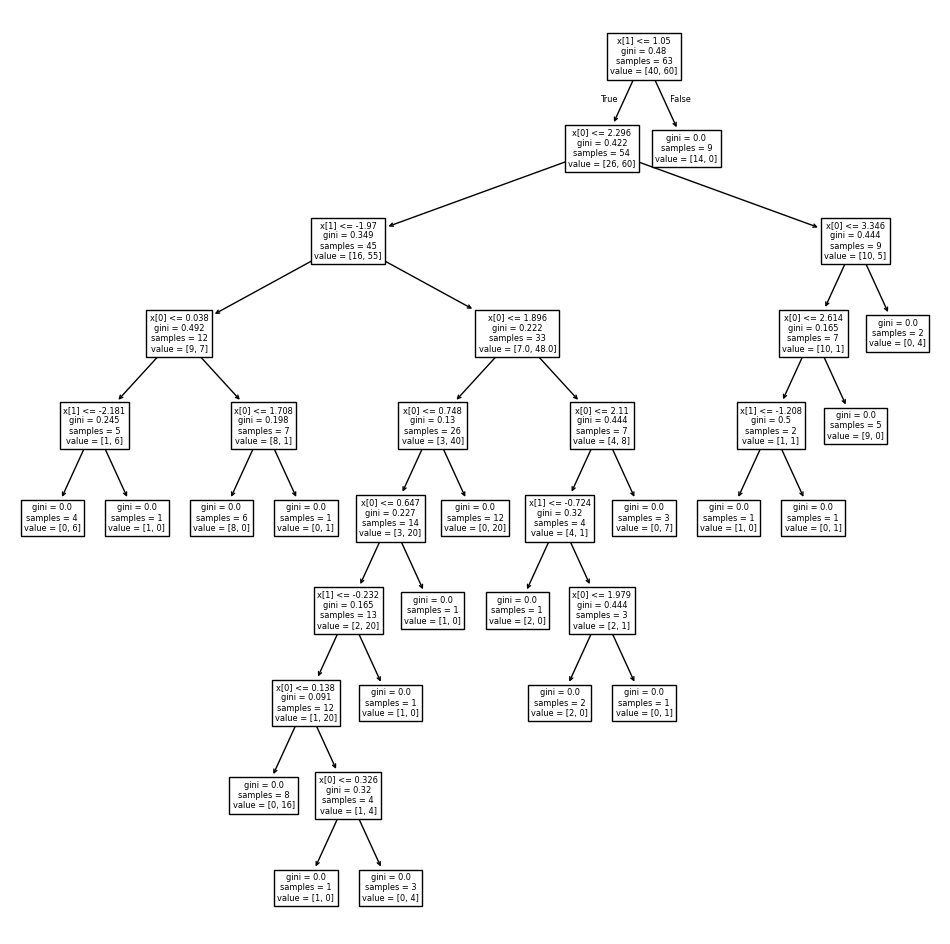

In [150]:
plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[0])
plt.show()

In [151]:
rf = RandomForestClassifier(max_features=2)

rf.fit(df.iloc[:,:5],df.iloc[:,-1])

RandomForestClassifier(max_features=2)

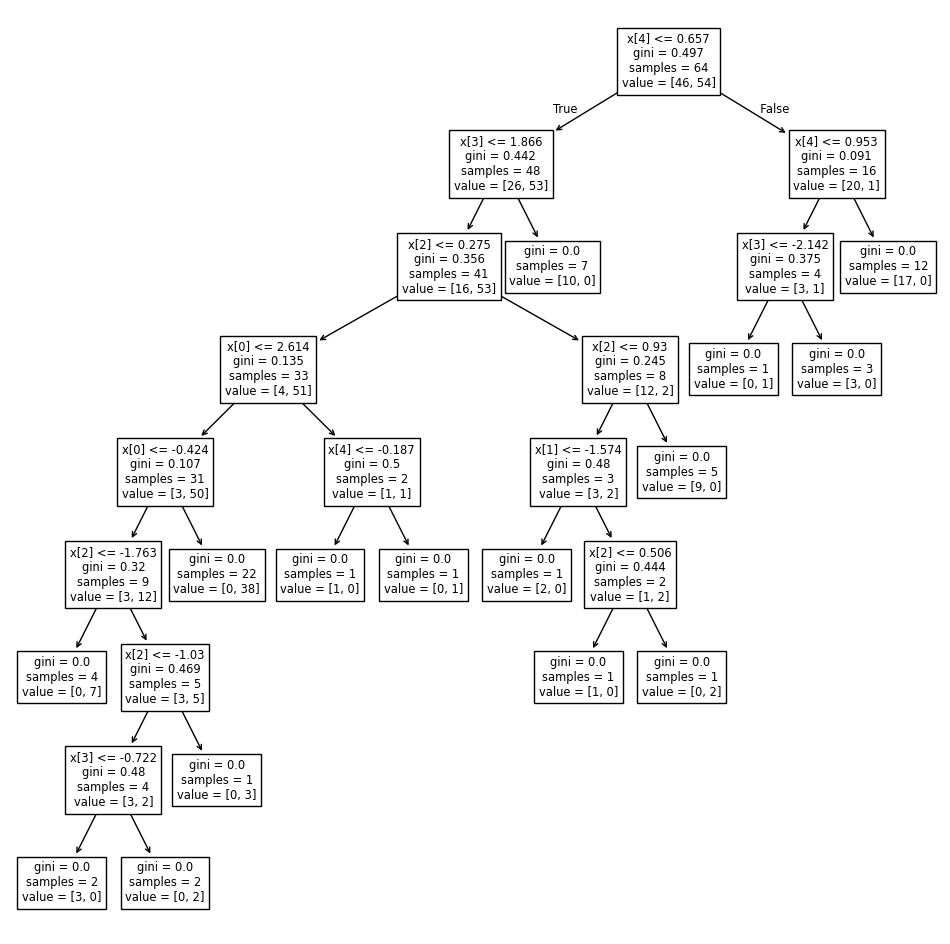

In [152]:
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[4])
plt.show()

# Hyperparameter Tuning

In [153]:
df = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [154]:
X = df.drop(columns={"target"})
y = df.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(820, 13)
(205, 13)


In [155]:
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svc = SVC()
lr = LogisticRegression(max_iter=1000)

In [156]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9853658536585366

In [157]:
gb.fit(X_train,y_train)
y_pred = gb.predict(X_test)
accuracy_score(y_test,y_pred)

0.9317073170731708

In [158]:
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
accuracy_score(y_test,y_pred)

0.6829268292682927

In [159]:
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test,y_pred)

0.7951219512195122

This shows that `RandomForestClassifier` gives best result withour `hyperparameter tuning`

In [160]:
rf = RandomForestClassifier(max_samples=0.75, random_state=42)

rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9853658536585366

In [161]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(rf,X,y,cv=10,scoring='accuracy'))

np.float64(0.9941462021701885)

# GridSearchCV

In [162]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

In [163]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples
             }

In [164]:
rf = RandomForestClassifier()

from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(estimator = rf, 
                       param_grid = param_grid, 
                       cv = 5, 
                       verbose=2, 
                       n_jobs = -1)

rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END bootstrap=None, max_depth=2, max_features=1.0, max_samples=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=20; total time=   0.0s
[CV] END bootstrap=None, max_depth=2, max_features=1.0, max_samples=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=20; total time=   0.0s
[CV] END bootstrap=None, max_depth=8, max_features=0.2, max_samples=0.5, min_samples_leaf=2, min_samples_split=2, n_estimators=120; total time=   0.0s
[CV] END bootstrap=None, max_depth=8, max_features=0.2, max_samples=0.5, min_samples_leaf=2, min_samples_split=2, n_estimators=120; total time=   0.0s
[CV] END bootstrap=None, max_depth=2, max_features=0.2, max_samples=0.5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=None, max_depth=2, max_features=0.2, max_samples=0.5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=None, max_dept

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.6, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'n_estimators': [20, 60, 100, 120]},
             verbose=2)

In [165]:
rf_grid.best_params_

{'max_depth': None,
 'max_features': 0.2,
 'max_samples': 1.0,
 'n_estimators': 20}

In [166]:
rf_grid.best_score_

np.float64(0.9853658536585366)

# RandomSearchCV

In [167]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

# Bootstrap samples
bootstrap = [True,None]

# Minimum number of samples required to split a node
min_samples_split = [2, 5]

In [168]:
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2]
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples,
              'bootstrap':bootstrap,
              'min_samples_split':min_samples_split,
              'min_samples_leaf':min_samples_leaf
             }

In [169]:
from sklearn.model_selection import RandomizedSearchCV

rf_grid = RandomizedSearchCV(estimator = rf, 
                       param_distributions = param_grid, 
                       cv = 5, 
                       verbose=2, 
                       n_jobs = -1)

rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

[CV] END max_depth=8, max_features=0.6, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END max_depth=8, max_features=0.6, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END max_depth=8, max_features=0.6, max_samples=0.5, n_estimators=60; total time=   0.2s
[CV] END max_depth=8, max_features=0.6, max_samples=0.5, n_estimators=100; total time=   0.4s
[CV] END max_depth=8, max_features=0.6, max_samples=0.5, n_estimators=100; total time=   0.4s
[CV] END max_depth=8, max_features=0.6, max_samples=0.5, n_estimators=120; total time=   0.4s
[CV] END max_depth=8, max_features=0.6, max_samples=0.5, n_estimators=120; total time=   0.5s
[CV] END max_depth=8, max_features=0.6, max_samples=0.75, n_estimators=100; total time=   0.4s
[CV] END max_depth=8, max_features=0.6, max_samples=0.75, n_estimators=100; total time=   0.4s
[CV] END max_depth=8, max_features=0.6, max_samples=1.0, n_estimators=20; total time=   0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, None],
                                        'max_depth': [2, 8, None],
                                        'max_features': [0.2, 0.6, 1.0],
                                        'max_samples': [0.5, 0.75, 1.0],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [20, 60, 100, 120]},
                   verbose=2)

In [170]:
rf_grid.best_params_

{'n_estimators': 120,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_samples': 0.75,
 'max_features': 0.2,
 'max_depth': None,
 'bootstrap': True}

In [171]:
rf_grid.best_score_

np.float64(0.9792682926829268)


[CV] END max_depth=8, max_features=1.0, max_samples=0.75, n_estimators=20; total time=   0.1s
[CV] END max_depth=8, max_features=1.0, max_samples=0.75, n_estimators=20; total time=   0.1s
[CV] END max_depth=8, max_features=1.0, max_samples=0.75, n_estimators=60; total time=   0.3s
[CV] END max_depth=8, max_features=1.0, max_samples=0.75, n_estimators=60; total time=   0.3s
[CV] END max_depth=8, max_features=1.0, max_samples=0.75, n_estimators=120; total time=   0.5s
[CV] END max_depth=8, max_features=1.0, max_samples=0.75, n_estimators=120; total time=   0.5s
[CV] END max_depth=8, max_features=1.0, max_samples=1.0, n_estimators=60; total time=   0.3s
[CV] END max_depth=8, max_features=1.0, max_samples=1.0, n_estimators=60; total time=   0.3s
[CV] END max_depth=8, max_features=1.0, max_samples=1.0, n_estimators=100; total time=   0.5s
[CV] END max_depth=8, max_features=1.0, max_samples=1.0, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, max_features=0.2, max_samples=0.5,

# OOB Score | Out of Bag Evaluation

In [172]:
rf = RandomForestClassifier(oob_score=True)
rf.fit(X_train,y_train)

RandomForestClassifier(oob_score=True)

In [173]:
rf.oob_score_

0.9939024390243902

In [174]:
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9853658536585366

# Feature Importance Using Random Forest

In [175]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [182]:
X = df.drop(columns=["label"])
y = df.label

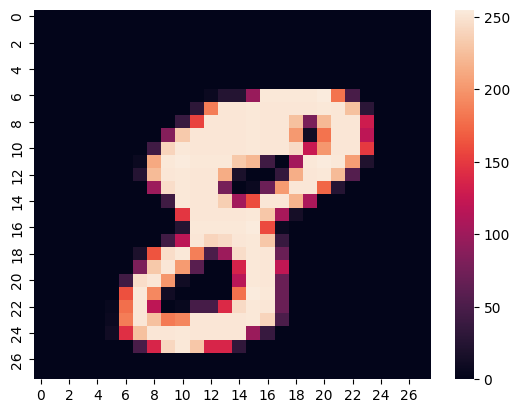

In [183]:
sns.heatmap(X.iloc[10].values.reshape(28,28))
plt.show()

In [184]:
rf = RandomForestClassifier()

rf.fit(X,y)

RandomForestClassifier()

In [185]:
rf.feature_importances_

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       4.93964022e-07, 0.00000000e+00, 1.03776468e-06, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.04637705e-06, 0.00000000e+00,
       5.46576256e-06, 3.49525879e-06, 1.38171917e-06, 0.00000000e+00,
       2.13546181e-06, 2.04961302e-06, 1.34830433e-06, 5.19124266e-06,
       4.76207198e-06, 2.87839013e-06, 1.24327448e-06, 5.18387769e-07,
       3.96925583e-07, 1.37487835e-06, 9.56238031e-07, 1.90096823e-06,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

<Axes: >

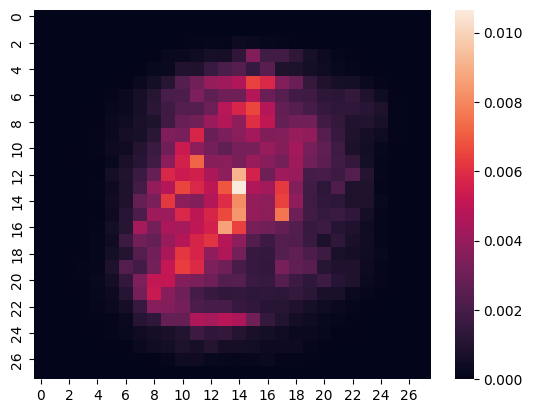

In [186]:
sns.heatmap(rf.feature_importances_.reshape(28,28))

# How Feature Importance Is Calculated

In [191]:
X,y = make_classification(n_samples=5, n_classes=2,
                               n_features=2, n_informative=2, n_redundant=0,
                               random_state=0)

In [192]:
clf = DecisionTreeClassifier()
clf.fit(X,y)

DecisionTreeClassifier()

[Text(0.4, 0.8333333333333334, 'x[1] <= -0.894\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= 1.01\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

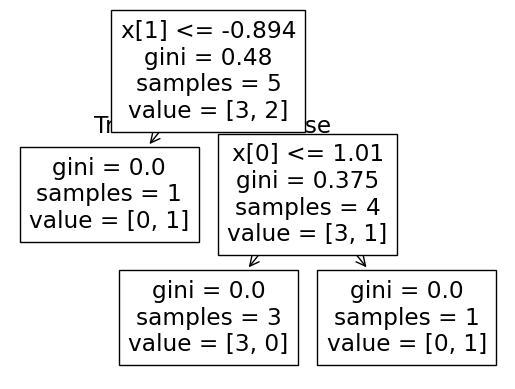

In [193]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [194]:
clf.feature_importances_

array([0.625, 0.375])

In [203]:
rf = RandomForestClassifier(n_estimators=5)
rf.fit(X,y)

RandomForestClassifier(n_estimators=5)

In [204]:
rf.feature_importances_

array([0.48263889, 0.51736111])

In [206]:
print(rf.estimators_[0].feature_importances_)
print(rf.estimators_[1].feature_importances_)
print(rf.estimators_[2].feature_importances_)
print(rf.estimators_[3].feature_importances_)
print(rf.estimators_[4].feature_importances_)

[1. 0.]
[0.55555556 0.44444444]
[0. 1.]
[0. 0.]
[0.375 0.625]
